In [31]:
import json
import pandas as pd
import os

data = []
base_path = os.path.dirname(os.getcwd())
log_dir = os.path.join(base_path, "log")

for file in os.listdir(log_dir):
    if file.endswith(".json"):
        file_path = os.path.join(log_dir, file)
        with open(file_path) as f:
            for line in f:
                data.append(json.loads(line))

df = pd.DataFrame(data)

print(df.head())

                  eventid          src_ip  src_port         dst_ip  dst_port  \
0  cowrie.session.connect   101.126.41.73   58982.0  172.31.45.231    2222.0   
1   cowrie.client.version   101.126.41.73       NaN            NaN       NaN   
2       cowrie.client.kex   101.126.41.73       NaN            NaN       NaN   
3   cowrie.session.closed   101.126.41.73       NaN            NaN       NaN   
4  cowrie.session.connect  175.27.145.234   18854.0  172.31.45.231    2222.0   

        session protocol                                            message  \
0  8fb6f3d375c6      ssh  New connection: 101.126.41.73:58982 (172.31.45...   
1  8fb6f3d375c6      ssh          Remote SSH version: SSH-2.0-libssh_0.11.1   
2  8fb6f3d375c6      ssh  SSH client hassh fingerprint: 03a80b21afa81068...   
3  8fb6f3d375c6      ssh                Connection lost after 120.0 seconds   
4  3921794b8300      ssh  New connection: 175.27.145.234:18854 (172.31.4...   

             sensor                         

In [32]:
sessions = []
print(df.columns)
grouped = df.groupby("session") #Agrupas el df por sesión
for session_id, group in grouped:
    #Diccionario de esta sesion
    session_data = {}

    #Guarda ID de la sesión
    session_data["session"] = session_id

    session_data["protocol"] = group["protocol"].dropna().iloc[0] if not group["protocol"].dropna().empty else None

    # IP atacante
    session_data["src_ip"] = group["src_ip"].dropna().iloc[0] if not group["src_ip"].dropna().empty else None

    # Puerto origen 
    session_data["src_port"] = group["src_port"].dropna().iloc[0] if not group["src_port"].dropna().empty else None

    session_data["username"] = group["username"].dropna().iloc[0] if not group["username"].dropna().empty else None
    session_data["password"] = group["password"].dropna().iloc[0] if not group["password"].dropna().empty else None

    # Duración segun evento cierre
    duration = group[group["eventid"] == "cowrie.session.closed"]["duration"]
    session_data["duration"] = float(duration.iloc[0]) if not duration.empty else 0

    # Login exitoso (1 = si, 0 = no)
    session_data["login_success"] = int((group["eventid"] == "cowrie.login.success").any())

    # Intentos de login fallidos
    session_data["login_attempts"] = (group["eventid"] == "cowrie.login.failed").sum()

    # Nº comandos ejecutados por el atacante 
    session_data["num_commands"] = (group["eventid"] == "cowrie.command.input").sum()

    # Descarga de archivos en la sesión (1 = sí, 0 = no)
    session_data["file_download"] = int((group["eventid"] == "cowrie.session.file_download").any())

    #Comandos atacante
    commands = group[group["eventid"] == "cowrie.command.input"]["input"].dropna().tolist()
    session_data["commands"] = commands

    #Distintos ataques en base a comandos
    # 1. Reconocimiento
    session_data["recon"] = int(
        any(any(x in cmd.lower() for x in ["uname","whoami","id","ifconfig","pwd"]) for cmd in commands)
    )

    # 2. Descarga malware
    session_data["download"] = int(
        any(any(x in cmd.lower() for x in ["wget","curl","tftp"]) for cmd in commands)
    )

    # 3. Cambio permisos
    session_data["chmod"] = int(
        any("chmod" in cmd.lower() for cmd in commands)
    )

    # 4. Ejecución de binarios/scripts
    session_data["execution"] = int(
        any(any(x in cmd.lower() for x in ["./","sh ","bash "]) for cmd in commands)
    )

    # 5. Persistencia
    session_data["persistence"] = int(
        any(".ssh" in cmd.lower() or "authorized_keys" in cmd.lower() for cmd in commands)
    )

    #Variedad de comandos en el ataque
    session_data["unique_commands"] = len(set(commands)) 

    #Complejidad del comando
    if commands:
        avg_len = sum(map(len, commands)) / len(commands)
    else:
        avg_len = 0
    session_data["avg_command_length"] = avg_len

    # Velocidad del ataque, alto->bot, bajo -> humano
    session_data["commands_per_second"] = (
        session_data["num_commands"] / session_data["duration"]
        if session_data["duration"] > 0 else 0
    )

    # Agrega diccionario de sesión
    sessions.append(session_data)
    
# Crea dataframe a partir de todos los diccionarios
dataset = pd.DataFrame(sessions)

print(dataset.head(50))

Index(['eventid', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'session',
       'protocol', 'message', 'sensor', 'uuid', 'timestamp', 'version',
       'hassh', 'hasshAlgorithms', 'kexAlgs', 'keyAlgs', 'encCS', 'macCS',
       'compCS', 'langCS', 'duration', 'username', 'password', 'arch', 'input',
       'ttylog', 'size', 'shasum', 'duplicate', 'outfile', 'destfile',
       'command', 'option_name', 'option_byte', 'width', 'height', 'data',
       'id', 'filename', 'fingerprint', 'key', 'type'],
      dtype='str')
         session protocol           src_ip  src_port username     password  \
0   000c6016f365      ssh   182.92.115.199   38932.0     root     1234aaaa   
1   00129065e16a      ssh   182.92.115.199   50294.0     root     19901224   
2   00151eed0959      ssh   182.92.115.199   58554.0     root     19840802   
3   00266650baf3      ssh   182.92.115.199   53760.0     root         ciao   
4   003158fba501      ssh   182.92.115.199   48530.0     root     19870422   
5   0033683

In [33]:
# Cuenta de cuantas veces nos ha atacado cada IP.
group_by_ip = dataset["src_ip"].value_counts()
print(group_by_ip)


src_ip
182.92.115.199     6192
60.23.187.159        82
83.222.191.62        60
195.178.110.114      45
101.126.41.73        35
                   ... 
58.115.51.223         1
183.171.56.123        1
85.229.46.153         1
102.90.34.90          1
180.76.104.208        1
Name: count, Length: 1071, dtype: int64


In [34]:
import geoip2.database

# Abrir la base de datos local
dic = {}
reader = geoip2.database.Reader('../db/GeoLite2-City.mmdb')
for i,k in  group_by_ip.items():

    response = reader.city(i)
    if response.country.name not in dic.keys():
        dic[response.country.name] = k
    else:
        dic[response.country.name] += k

reader.close()

print(dic)


{'China': 6588, 'Bulgaria': 125, 'Seychelles': 37, 'India': 197, 'South Africa': 24, 'South Korea': 140, 'Germany': 37, 'Hong Kong': 53, 'Canada': 21, 'Indonesia': 33, 'Russia': 89, 'Brazil': 53, 'United States': 364, 'France': 23, 'Malaysia': 72, 'Iran': 13, 'Ethiopia': 16, 'Hungary': 4, 'Thailand': 8, 'Vietnam': 17, 'Singapore': 8, 'Sweden': 44, 'Bangladesh': 10, 'Iraq': 42, 'Türkiye': 10, 'Taiwan': 33, 'Australia': 5, 'Rwanda': 3, 'Antigua and Barbuda': 3, 'Ghana': 4, 'Switzerland': 3, 'Lithuania': 4, 'Afghanistan': 5, 'Colombia': 7, 'Japan': 11, 'Ukraine': 7, 'Israel': 14, 'Italy': 7, 'United Kingdom': 19, 'Zimbabwe': 2, 'Finland': 2, 'Netherlands': 7, 'Iceland': 2, 'Mozambique': 4, 'Norway': 2, 'Pakistan': 3, 'Venezuela': 4, 'Ireland': 4, 'Mexico': 3, 'Portugal': 4, 'New Zealand': 4, 'Spain': 9, 'Argentina': 2, 'Chile': 3, 'Belarus': 1, 'Poland': 5, 'Nicaragua': 1, 'Greece': 1, 'El Salvador': 1, 'Belgium': 1, 'Kazakhstan': 3, 'Syria': 1, 'Peru': 3, 'Nigeria': 2, 'Senegal': 1, 'Uni

In [50]:
# Comandos ejecutados

dataset_filtrado = dataset[dataset["commands"].str.len() > 0]

set_comandos = set([x for xs in dataset_filtrado["commands"].tolist() for x in xs])
for idx, i in enumerate(set_comandos):
    print(idx, " ", i)


0   
1   which ls
2   head -c 8308096 > /tmp/ptK3WDjBWY
3   df -h | head -n 2 | awk 'FNR == 2 {print $2;}'
4   uname
5   echo -e "\x6F\x6B"
6   crontab -l
7   ps -ef | grep '[Mm]iner'
8   cd ~; chattr -ia .ssh; lockr -ia .ssh
9   cat /proc/cpuinfo | grep name | wc -l
10   cd /dev/shm; cat .s || cp /bin/echo .s; /bin/busybox IZORG
11   chmod +x clean.sh; sh clean.sh; rm -rf clean.sh; chmod +x setup.sh; sh setup.sh; rm -rf setup.sh; mkdir -p ~/.ssh; chattr -ia ~/.ssh/authorized_keys; echo "ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAABAQCqHrvnL6l7rT/mt1AdgdY9tC1GPK216q0q/7neNVqm7AgvfJIM3ZKniGC3S5x6KOEApk+83GM4IKjCPfq007SvT07qh9AscVxegv66I5yuZTEaDAG6cPXxg3/0oXHTOTvxelgbRrMzfU5SEDAEi8+ByKMefE+pDVALgSTBYhol96hu1GthAMtPAFahqxrvaRR4nL4ijxOsmSLREoAb1lxiX7yvoYLT45/1c5dJdrJrQ60uKyieQ6FieWpO2xF6tzfdmHbiVdSmdw0BiCRwe+fuknZYQxIC1owAj2p5bc+nzVTi3mtBEk9rGpgBnJ1hcEUslEf/zevIcX8+6H7kUMRr rsa-key-20230629" > ~/.ssh/authorized_keys; chattr +ai ~/.ssh/authorized_keys; uname -a; echo -e "\x61\x75\x74\x68\x5F\x6F\x6B

In [36]:
low = 0
med = 0
high = 0
for i in dataset["duration"]:
    if i < 20:
        low += 1
    if 20 <= i < 80:
        med += 1
    if i >= 80:
        high += 1
print("Low duration connections: ", low)
print("Medium duration connections: ", med)
print("High duration connections: ", high)



Low duration connections:  7837
Medium duration connections:  154
High duration connections:  253


In [37]:
print(dataset["protocol"].value_counts())

protocol
ssh       7858
telnet     386
Name: count, dtype: int64


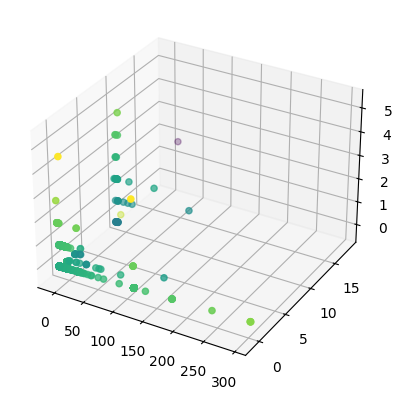

In [38]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

data_scaled = scaler.fit(dataset[["duration","login_attempts","num_commands","file_download","recon","download","chmod","execution","persistence","commands_per_second"]])
X = np.array(dataset[["duration","login_attempts","num_commands","file_download","recon","download","chmod","execution","persistence","commands_per_second"]])
pca = PCA(n_components=4)
pca_results = pca.fit_transform(X)
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(pca_results[:,0],pca_results[:,1],pca_results[:,2], c=pca_results[:,3])

plt.show()
